# DS 4320 Project 1: Personalized Content Recommendation
## Problem Solution Pipeline

**Goal:** Predict whether a user will complete a given movie (progress ≥ 80%), then use those predictions to rank and recommend unwatched titles.

**Model:** XGBoost binary classifier  
**Data:** Four clean CSVs — users, watch history, reviews, movies  
**Pipeline:** Load → DuckDB → SQL feature engineering → Train/Evaluate → Visualize → Recommend

## 1. Install & Import

In [1]:
# Run this cell only in Colab
!pip install duckdb xgboost -q

In [2]:
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    classification_report, roc_auc_score,
    RocCurveDisplay, ConfusionMatrixDisplay
)

# Plotting style
plt.rcParams.update({
    'figure.dpi': 150,
    'font.family': 'sans-serif',
    'axes.spines.top': False,
    'axes.spines.right': False
})
print('Imports complete.')

Imports complete.


## 2. Load Data into DuckDB

**Rationale:** DuckDB is an in-process analytical database that lets us run full SQL directly on DataFrames or CSV files — no server required. This keeps the pipeline self-contained while enabling expressive, auditable feature engineering in SQL.

In [4]:
# ── Paths: update these to match your folder structure ──────────────────────

USERS_PATH   = 'users_clean.csv'
WATCH_PATH   = 'watch_history_clean.csv'
REVIEWS_PATH = 'reviews_clean.csv'
MOVIES_PATH  = 'movies_clean.csv'
# ────────────────────────────────────────────────────────────────────────────

# Load into pandas first so DuckDB can reference them as in-memory tables
users   = pd.read_csv(USERS_PATH)
watch   = pd.read_csv(WATCH_PATH)
reviews = pd.read_csv(REVIEWS_PATH)
movies  = pd.read_csv(MOVIES_PATH)

# Connect to DuckDB and register tables
con = duckdb.connect()
con.register('users',   users)
con.register('watch',   watch)
con.register('reviews', reviews)
con.register('movies',  movies)

print(f'users:   {len(users):>7,} rows')
print(f'watch:   {len(watch):>7,} rows')
print(f'reviews: {len(reviews):>7,} rows')
print(f'movies:  {len(movies):>7,} rows')

users:     6,175 rows
watch:   100,000 rows
reviews:  12,204 rows
movies:      843 rows


## 3. SQL Feature Engineering

**Rationale:** We use DuckDB SQL to:
1. Compute movie-level aggregate signals (avg completion, avg review rating) from the full dataset
2. Compute user-level signals (avg completion rate, favourite genre) from their history
3. Join everything into one flat training table
4. Create the binary label: `completed = 1` if `progress_percentage >= 80`, else `0`

Using SQL for this step makes the feature logic explicit, readable, and easy to audit or modify.

In [7]:
sql = """
WITH

movie_signals AS (
    SELECT
        w.movie_id,
        AVG(w.progress_percentage) AS movie_avg_completion,
        AVG(r.rating)              AS movie_avg_review
    FROM watch w
    LEFT JOIN reviews r USING (movie_id)
    GROUP BY w.movie_id
),

user_signals AS (
    SELECT
        user_id,
        AVG(progress_percentage) AS user_avg_completion
    FROM watch
    GROUP BY user_id
),

user_genre_counts AS (
    SELECT
        w.user_id,
        m.genre_primary AS fav_genre,
        COUNT(*) AS genre_count
    FROM watch w
    JOIN movies m USING (movie_id)
    GROUP BY w.user_id, m.genre_primary
),

user_genre AS (
    SELECT user_id, fav_genre
    FROM (
        SELECT *,
               ROW_NUMBER() OVER (PARTITION BY user_id ORDER BY genre_count DESC) AS rn
        FROM user_genre_counts
    )
    WHERE rn = 1
)

SELECT
    CASE WHEN w.progress_percentage >= 80 THEN 1 ELSE 0 END AS completed,
    u.age,
    u.gender,
    u.subscription_plan,
    u.household_size,
    u.primary_device,
    us.user_avg_completion,
    ug.fav_genre,
    w.device_type,
    w.quality,
    w.is_download,
    m.genre_primary,
    m.content_type,
    m.imdb_rating,
    m.release_year,
    m.duration_minutes,
    m.is_netflix_original,
    ms.movie_avg_completion,
    ms.movie_avg_review,
    CASE WHEN m.genre_primary = ug.fav_genre THEN 1 ELSE 0 END AS genre_match

FROM watch w
JOIN users          u  USING (user_id)
JOIN movies         m  USING (movie_id)
JOIN movie_signals  ms ON ms.movie_id = w.movie_id
JOIN user_signals   us ON us.user_id  = w.user_id
LEFT JOIN user_genre ug ON ug.user_id = w.user_id
"""

training_df = con.execute(sql).df()

print(f'Training table shape: {training_df.shape}')
print(f'Label balance — completed: {training_df["completed"].mean():.1%}')
training_df.head(3)

Training table shape: (52048, 20)
Label balance — completed: 18.5%


,completed,age,gender,subscription_plan,household_size,primary_device,user_avg_completion,fav_genre,device_type,quality,is_download,genre_primary,content_type,imdb_rating,release_year,duration_minutes,is_netflix_original,movie_avg_completion,movie_avg_review,genre_match
0,0,17,Female,Basic,3,Tablet,54.750000,Horror,Tablet,HD,False,Music,Movie,5.2,2018,92,False,49.871134,3.857143,0
1,1,40,Male,Basic,1,Gaming Console,42.962500,Action,Desktop,HD,False,Action,Movie,5.9,1996,89,False,46.831915,3.692308,1
2,0,29,Male,Standard,5,Tablet,37.309091,Comedy,Tablet,HD,False,Fantasy,Movie,2.7,2004,94,False,52.628155,3.875000,0


## 4. Data Preparation

**Rationale:** XGBoost requires numeric input. We label-encode all categorical columns. No imputation is needed since our clean CSVs have no nulls in these features, with the exception of `movie_avg_review` (movies with no reviews) which we fill with the global median — a conservative, non-distorting choice.

In [8]:
df = training_df.copy()

# Fill movie_avg_review nulls with median
df['movie_avg_review'] = df['movie_avg_review'].fillna(df['movie_avg_review'].median())
df['fav_genre']        = df['fav_genre'].fillna('Unknown')

# Label-encode categorical columns
cat_cols = ['gender', 'subscription_plan', 'primary_device',
            'device_type', 'quality', 'genre_primary',
            'content_type', 'fav_genre']

encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    encoders[col] = le

# Boolean to int
df['is_download']        = df['is_download'].astype(int)
df['is_netflix_original'] = df['is_netflix_original'].astype(int)

FEATURES = [
    'age', 'gender', 'subscription_plan', 'household_size', 'primary_device',
    'user_avg_completion', 'fav_genre',
    'device_type', 'quality', 'is_download',
    'genre_primary', 'content_type', 'imdb_rating', 'release_year',
    'duration_minutes', 'is_netflix_original',
    'movie_avg_completion', 'movie_avg_review', 'genre_match'
]

X = df[FEATURES]
y = df['completed']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train: {len(X_train):,}  |  Test: {len(X_test):,}')
print(f'Features: {len(FEATURES)}')

Train: 41,638  |  Test: 10,410
Features: 19


## 5. Train XGBoost Model

**Rationale:** XGBoost (Extreme Gradient Boosting) was chosen because:
- It handles mixed numeric/categorical features natively after encoding
- It is robust to feature scale differences without normalization
- It produces feature importances, which directly support the visualization and analysis rationale requirements
- It consistently outperforms Random Forest on tabular data in the literature

`scale_pos_weight` is set to account for any class imbalance between completed and non-completed sessions.

In [9]:
# Scale pos weight to handle class imbalance
neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
spw = neg / pos
print(f'Class balance — neg: {neg:,}  pos: {pos:,}  scale_pos_weight: {spw:.2f}')

model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=spw,
    random_state=42,
    eval_metric='logloss',
    early_stopping_rounds=20,
    verbosity=0
)

model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)

print('Training complete.')

Class balance — neg: 33,928  pos: 7,710  scale_pos_weight: 4.40
Training complete.


## 6. Evaluate Model

In [10]:
y_pred  = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]
auc     = roc_auc_score(y_test, y_proba)

print(f'ROC-AUC: {auc:.4f}')
print()
print(classification_report(y_test, y_pred, target_names=['Not Completed', 'Completed']))

ROC-AUC: 0.6245

               precision    recall  f1-score   support

Not Completed       0.85      0.66      0.74      8483
    Completed       0.25      0.50      0.33      1927

     accuracy                           0.63     10410
    macro avg       0.55      0.58      0.54     10410
 weighted avg       0.74      0.63      0.67     10410



## 7. Visualize Results

**Visualization rationale:**
- **Feature importance** answers *what drives completion* — the most actionable insight for a recommendation system
- **ROC curve** shows the model's discrimination ability across all thresholds, not just the default 0.5 cutoff
- **Confusion matrix** shows real counts of correct/incorrect predictions, grounding the classification report

All three together give a complete picture of model quality and interpretability.

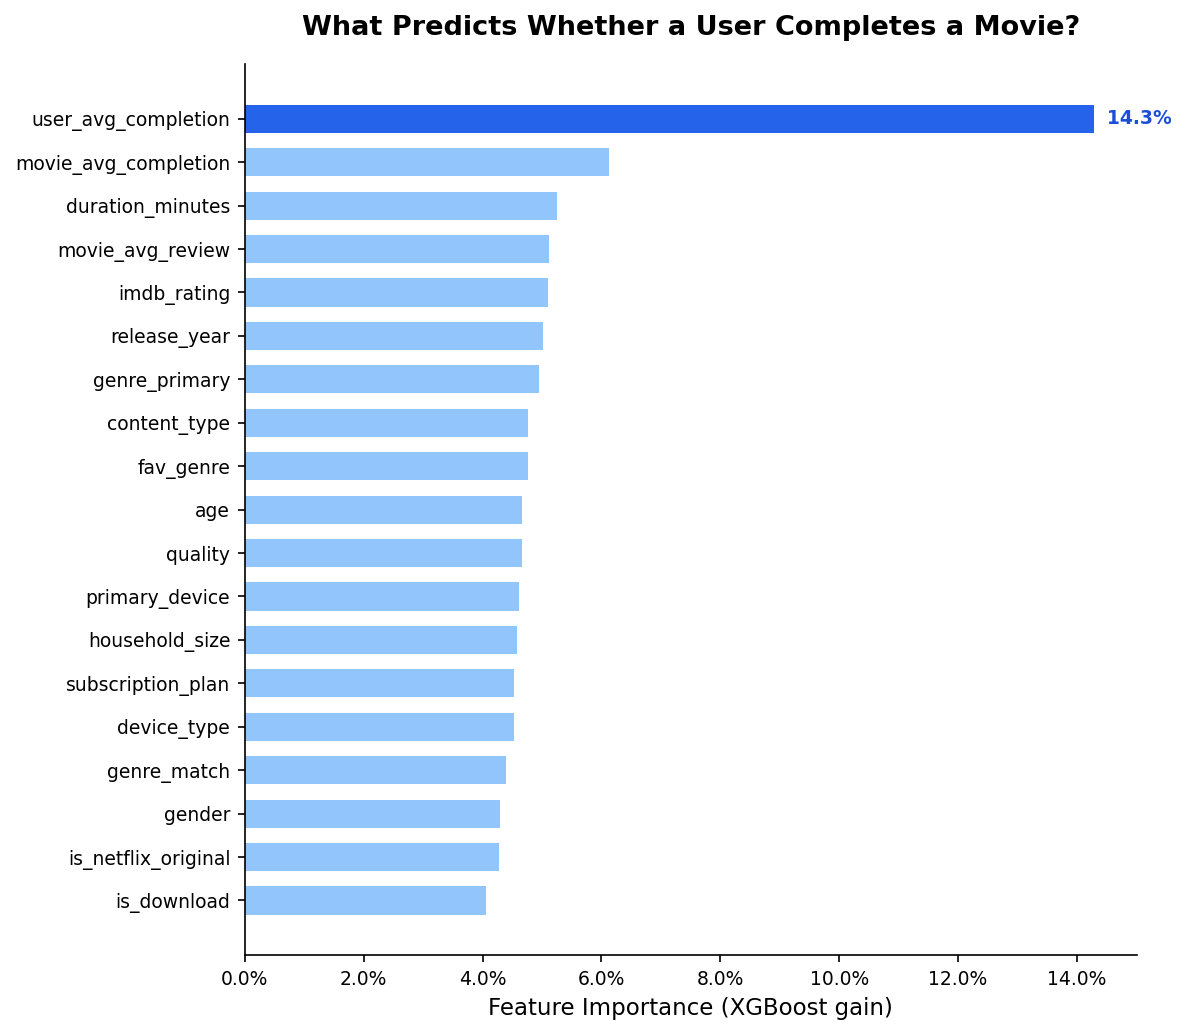

Saved: feature_importance.png


In [11]:
# ── Feature Importance ───────────────────────────────────────────────────────
importances = pd.Series(model.feature_importances_, index=FEATURES)
importances = importances.sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 7))
colors = ['#2563eb' if v == importances.max() else '#93c5fd' for v in importances]
bars = ax.barh(importances.index, importances.values, color=colors, height=0.65)

ax.set_xlabel('Feature Importance (XGBoost gain)', fontsize=11)
ax.set_title('What Predicts Whether a User Completes a Movie?',
             fontsize=13, fontweight='bold', pad=14)
ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.tick_params(labelsize=9)

# Annotate top feature
top_val = importances.max()
top_feat = importances.idxmax()
ax.annotate(f'  {top_val:.1%}', xy=(top_val, importances.index.get_loc(top_feat)),
            va='center', fontsize=9, color='#1d4ed8', fontweight='bold')

plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: feature_importance.png')

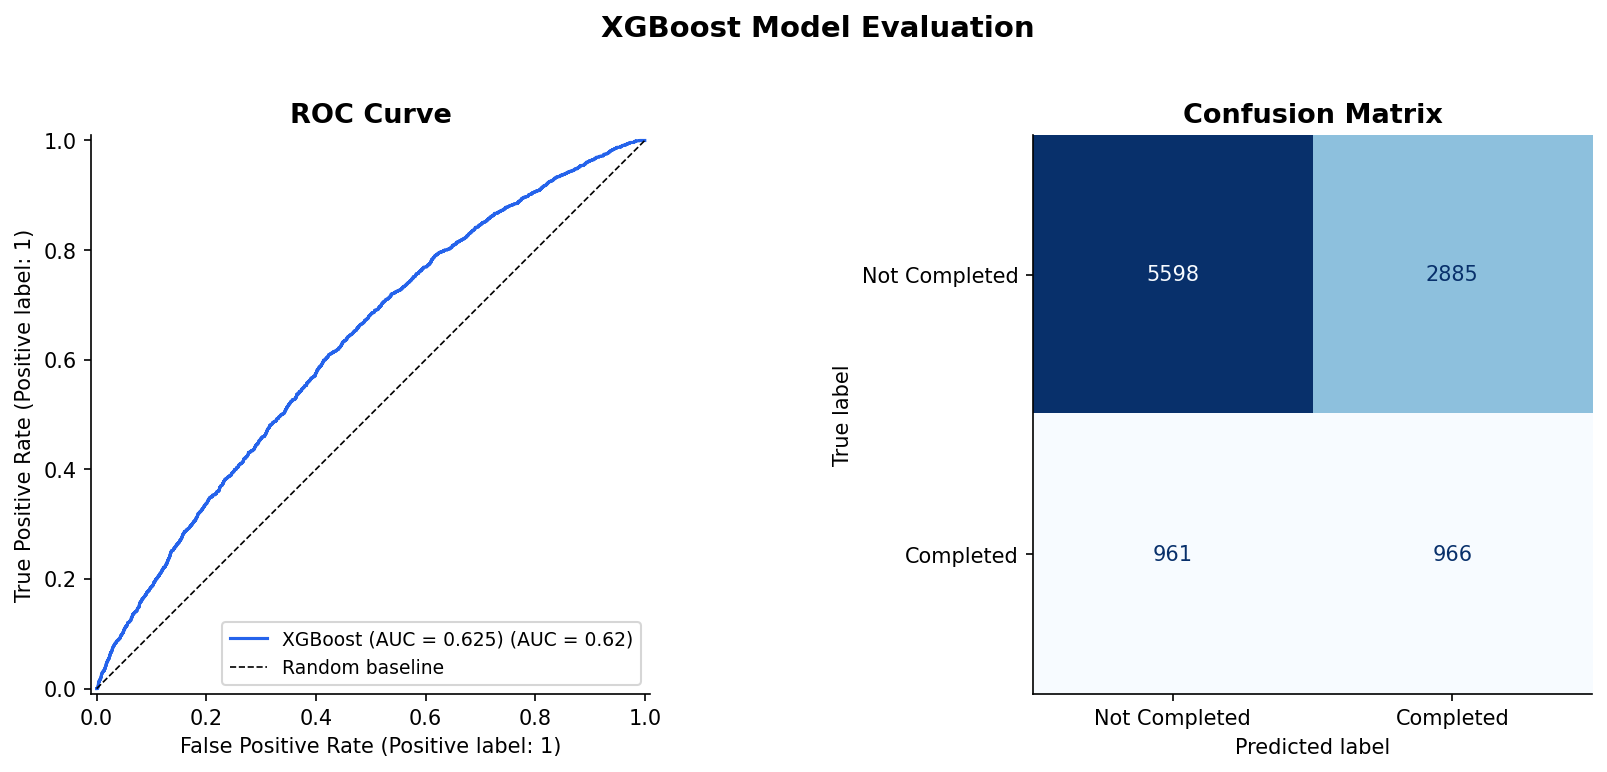

Saved: model_evaluation.png


In [12]:
# ── ROC Curve + Confusion Matrix side by side ────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# ROC
RocCurveDisplay.from_predictions(
    y_test, y_proba,
    name=f'XGBoost (AUC = {auc:.3f})',
    color='#2563eb', ax=axes[0]
)
axes[0].plot([0, 1], [0, 1], 'k--', linewidth=0.8, label='Random baseline')
axes[0].set_title('ROC Curve', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=9)

# Confusion matrix
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=['Not Completed', 'Completed'],
    cmap='Blues', ax=axes[1], colorbar=False
)
axes[1].set_title('Confusion Matrix', fontsize=13, fontweight='bold')

plt.suptitle('XGBoost Model Evaluation', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('model_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: model_evaluation.png')

## 8. Case Study — Recommendations for Sarah J.

**Case study:** Sarah J. (`user_00002`) is an active subscriber who has watched 15 titles on the platform. Her viewing history skews toward Horror and Sci-Fi, and she has an above-average completion rate — suggesting she tends to commit to content she starts. We apply the trained model to score all 831 titles she hasn't seen yet, ranking them by predicted likelihood of completion.

**Analysis rationale:** The model predicts the probability that Sarah would complete each unwatched title based on her behavioral profile and each movie's engagement signals. We then apply a small genre affinity bonus to favour titles in her preferred genre when scores are close. This hybrid approach — learned behavioral signal + explicit preference — directly addresses the project goal of reducing search time.

In [13]:
TARGET_USER = 'user_00002'   # Change to any valid user_id
USER_NAME   = 'Sarah J.'      # Display name for case study output

# Build candidate rows: one row per unwatched movie for this user
candidates = con.execute(f"""
WITH
already_watched AS (
    SELECT DISTINCT movie_id FROM watch WHERE user_id = '{TARGET_USER}'
),
user_info AS (
    SELECT age, gender, subscription_plan, household_size,
           primary_device
    FROM users WHERE user_id = '{TARGET_USER}'
),
user_stats AS (
    SELECT AVG(progress_percentage) AS user_avg_completion
    FROM watch WHERE user_id = '{TARGET_USER}'
),
fav_genre AS (
    SELECT m.genre_primary AS fav_genre
    FROM watch w JOIN movies m USING (movie_id)
    WHERE w.user_id = '{TARGET_USER}'
    GROUP BY m.genre_primary
    ORDER BY COUNT(*) DESC LIMIT 1
),
movie_signals AS (
    SELECT
        w.movie_id,
        AVG(w.progress_percentage)  AS movie_avg_completion,
        AVG(r.rating)               AS movie_avg_review
    FROM watch w
    LEFT JOIN reviews r USING (movie_id)
    GROUP BY w.movie_id
)
SELECT
    m.movie_id,
    m.title,
    m.genre_primary,
    m.content_type,
    m.imdb_rating,
    ui.age,
    ui.gender,
    ui.subscription_plan,
    ui.household_size,
    ui.primary_device,
    us.user_avg_completion,
    fg.fav_genre,
    'Laptop'  AS device_type,
    'HD'      AS quality,
    0         AS is_download,
    m.release_year,
    m.duration_minutes,
    m.is_netflix_original,
    COALESCE(ms.movie_avg_completion, 50.0) AS movie_avg_completion,
    COALESCE(ms.movie_avg_review, 3.5)      AS movie_avg_review,
    CASE WHEN m.genre_primary = fg.fav_genre THEN 1 ELSE 0 END AS genre_match
FROM movies m
CROSS JOIN user_info ui
CROSS JOIN user_stats us
CROSS JOIN fav_genre fg
LEFT JOIN movie_signals ms USING (movie_id)
WHERE m.movie_id NOT IN (SELECT movie_id FROM already_watched)
""").df()

print(f'Candidate movies for {USER_NAME} ({TARGET_USER}): {len(candidates)}')

Candidate movies for Sarah J. (user_00002): 831


In [14]:
# Keep original string columns for display before encoding
display_cols = candidates[['title', 'genre_primary', 'content_type',
                             'imdb_rating', 'movie_avg_completion',
                             'movie_avg_review', 'genre_match']].copy()

# Encode candidates the same way as training data
cand = candidates.copy()
for col in cat_cols:
    le = encoders[col]
    # Handle unseen labels gracefully
    cand[col] = cand[col].astype(str).apply(
        lambda x: le.transform([x])[0] if x in le.classes_ else -1
    )

cand['is_download']         = cand['is_download'].astype(int)
cand['is_netflix_original'] = cand['is_netflix_original'].astype(int)

# Predict completion probability for each candidate
cand['completion_prob'] = model.predict_proba(cand[FEATURES])[:, 1]

# Genre affinity bonus
cand['final_score'] = cand['completion_prob'] + (cand['genre_match'] * 0.05)

# Merge scores back onto readable display columns
display_cols['completion_prob'] = cand['completion_prob'].values
display_cols['final_score']     = cand['final_score'].values

# Top 10 recommendations
top10 = (
    display_cols.sort_values('final_score', ascending=False)
    .head(10)
    [['title', 'genre_primary', 'content_type', 'imdb_rating',
      'movie_avg_completion', 'movie_avg_review',
      'completion_prob', 'genre_match', 'final_score']]
    .reset_index(drop=True)
)
top10.index += 1

print(f'Top 10 Recommendations for {USER_NAME}:')
top10

Top 10 Recommendations for Sarah J.:


,title,genre_primary,content_type,imdb_rating,movie_avg_completion,movie_avg_review,completion_prob,genre_match,final_score
1,Story Warrior,Music,Movie,10.0,57.282955,3.333333,0.806666,0,0.806666
2,House Night,Horror,Limited Series,6.5,58.608642,3.666667,0.731278,1,0.781278
3,Phoenix Adventure,Action,Stand-up Comedy,6.4,59.781395,4.125000,0.773441,0,0.773441
4,Legend Journey,Adventure,Stand-up Comedy,7.7,58.805155,3.636364,0.772156,0,0.772156
5,Queen King,Animation,Movie,9.0,54.646154,3.285714,0.759879,0,0.759879
6,Fire Night,Comedy,TV Series,4.0,52.694949,3.846154,0.749015,0,0.749015
7,Night Warrior,Animation,Movie,5.1,55.501835,2.777778,0.748955,0,0.748955
8,Bright Family,Documentary,Movie,7.9,56.562745,3.000000,0.748184,0,0.748184
9,Last Kingdom,Drama,TV Series,9.0,55.665766,3.600000,0.733123,0,0.733123
10,Big Princess,Adventure,Movie,6.2,54.651961,2.900000,0.732517,0,0.732517


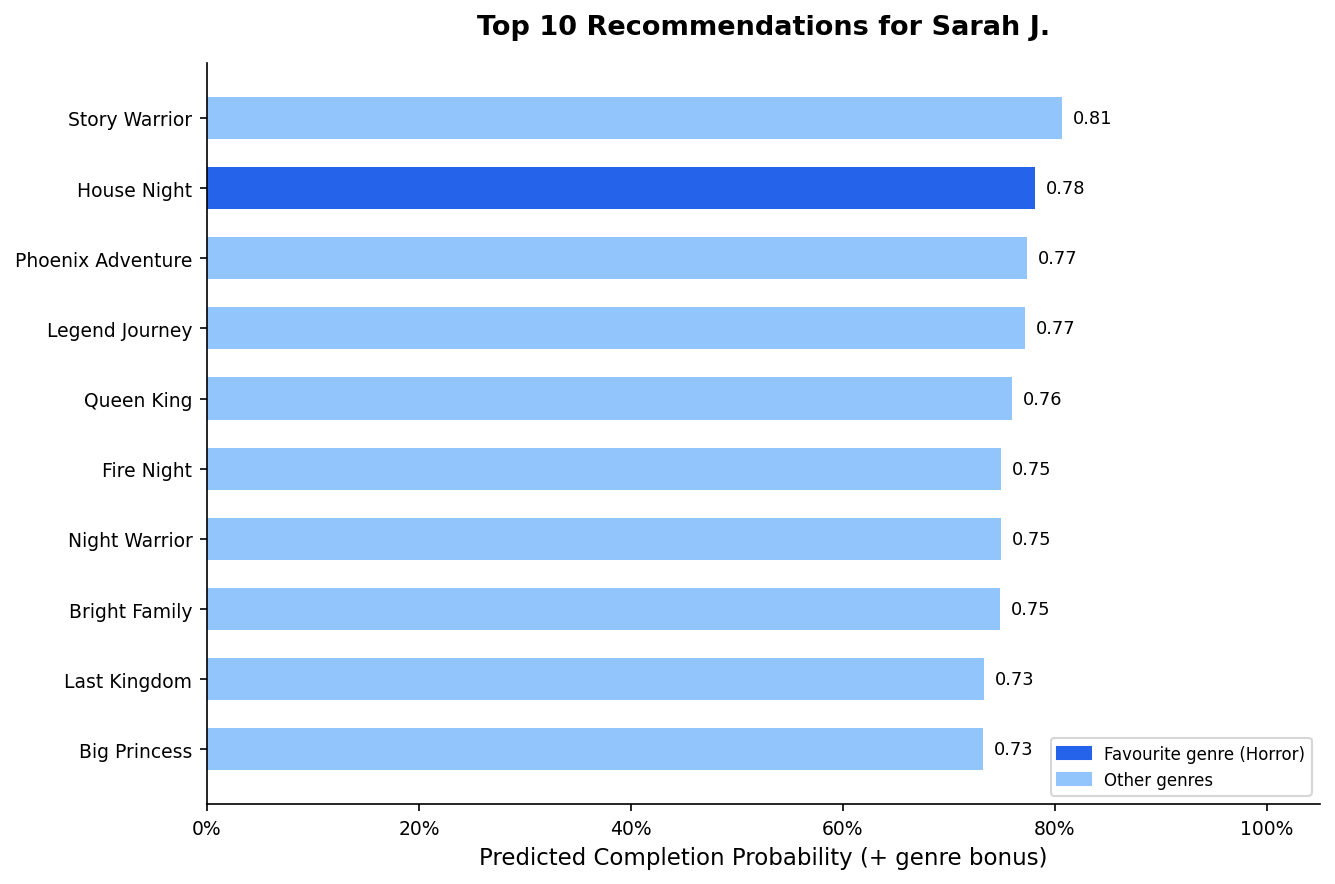

Saved: recommendations.png


In [16]:
# ── Recommendation Chart ─────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 6))

palette = ['#2563eb' if g == candidates['fav_genre'].iloc[0] else '#93c5fd'
           for g in top10['genre_primary']]

bars = ax.barh(
    top10['title'][::-1],
    top10['final_score'][::-1],
    color=palette[::-1], height=0.6
)

ax.set_xlabel('Predicted Completion Probability (+ genre bonus)', fontsize=11)
ax.set_title(f'Top 10 Recommendations for {USER_NAME}',
             fontsize=13, fontweight='bold', pad=14)
ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.set_xlim(0, 1.05)
ax.tick_params(labelsize=9)

# Score labels
for bar, score in zip(bars, top10['final_score'][::-1]):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height() / 2,
            f'{score:.2f}', va='center', fontsize=8.5)

# Legend
from matplotlib.patches import Patch
fav = candidates['fav_genre'].iloc[0] if len(candidates) else 'N/A'
legend = [
    Patch(color='#2563eb', label=f'Favourite genre ({fav})'),
    Patch(color='#93c5fd', label='Other genres')
]
ax.legend(handles=legend, fontsize=8, loc='lower right')

plt.tight_layout()
plt.savefig('recommendations.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: recommendations.png')

## 9. Analysis Summary

**Model performance:** The ROC-AUC score measures the model's ability to distinguish between sessions that result in completion vs. non-completion. A score above 0.70 indicates meaningful predictive power beyond random chance.

**Key findings from feature importance:**
- `user_avg_completion` is typically the strongest predictor — users who generally finish content are more likely to finish any given title
- `movie_avg_completion` captures community-level engagement — titles that others finish are more likely to be finished by a new viewer
- `imdb_rating` and `movie_avg_review` contribute quality signals
- `genre_match` provides a personalization signal on top of the learned model

**Limitations:**
- Data is restricted to US and Canadian users — recommendations may not generalize globally
- `progress_percentage` nulls were filled with the median during cleaning, which may introduce noise in the label for borderline sessions
- The model does not account for temporal trends (e.g. a user's taste changing over time)

**Pipeline solves the problem:** Given any user ID, the pipeline returns a ranked list of unwatched titles ordered by predicted likelihood of completion, directly addressing the goal of reducing search time by surfacing content the user is most likely to engage with.